# 03 — Agregación a resolución horaria

**Qué hace este notebook y por qué.**

El dataset registra una fila cada 20 s, pero el target (`% Silica Concentrate`) viene de
análisis de laboratorio **horario**: el mismo valor se replica ~180 veces. Eso infla el
número de filas sin añadir información sobre la variable que quieres predecir, y falsea
cualquier métrica calculada a nivel de fila.

Aquí se colapsa cada hora en una única muestra:

- **Target** → el valor de laboratorio de esa hora (no se agrega, se toma tal cual).
- **Features** → `media` y `std` de las 180 muestras. La media da el nivel de operación;
  la std da la variabilidad intra-hora, que en flotación es señal de inestabilidad y se
  perdería tomando solo la media.

**Salida:** `datos_horarios.parquet`, que consume el notebook 04.

---

### Lo que vas a descubrir al ejecutarlo
El recuento de horas útiles. Los ~700.000 registros originales se convierten en unos
pocos miles de muestras reales. Ese número —y la ratio filas/features que sale de él— es
el que decide qué modelos son razonables a partir de aquí. Léelo antes de seguir al
notebook 04.

## 1. Configuración

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

DATA_PATH   = Path("../Datasets/MiningProcess_Flotation_Plant_Database.csv")
OUTPUT_PATH = Path("datos_horarios.parquet")

TIMESTAMP_COL = "date"
TARGET        = "% Silica Concentrate"

SAMPLING_SECONDS = 20
ESPERADAS_POR_HORA = 3600 // SAMPLING_SECONDS      # 180

# Una hora con muy pocas muestras no da una media ni una std fiables.
MIN_MUESTRAS_HORA = 120        # ~2/3 de la hora
GAP_LIMIT_HORAS   = 3          # salto > 3 h -> corta bloque
FROZEN_MIN_HORAS  = 12         # variable congelada >= 12 h -> sensor muerto
MIN_BLOCK_HORAS   = 48         # bloques menores no dan para lags

## 2. Carga y tipado

In [2]:
data = pd.read_csv(DATA_PATH)
data[TIMESTAMP_COL] = pd.to_datetime(data[TIMESTAMP_COL])

for col in data.select_dtypes(include=["object"]).columns:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace(",", "."), errors="coerce"
    )

data = data.sort_values(TIMESTAMP_COL).reset_index(drop=True)

print(f"Filas originales: {len(data):,}")
print(f"Rango: {data[TIMESTAMP_COL].min()} -> {data[TIMESTAMP_COL].max()}")
print(f"Nulos: {int(data.isna().sum().sum())}")
data.head(3)

Filas originales: 737,453
Rango: 2017-03-10 01:00:00 -> 2017-09-09 23:00:00
Nulos: 0


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3185.55,586.182,404.648,10.1139,1.73614,250.488,250.488,249.214,295.096,306.4,250.137,248.950,450.139,510.332,461.638,422.888,451.528,510.098,513.904,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3182.03,595.947,407.168,10.1135,1.73545,250.620,252.334,249.390,295.096,306.4,256.465,251.499,440.530,518.600,465.414,405.704,433.686,513.794,512.252,66.91,1.31


## 3. Cómo está registrado realmente el target

No es homogéneo. El target aparece en **dos regímenes distintos** dentro del mismo
archivo:

- **~92 % de las horas** — un único valor de laboratorio replicado en las 180 filas.
- **~8 % de las horas** — 180 valores todos distintos, dispersos alrededor de un valor
  central, con incrementos que caen sobre una rejilla de paso fijo (~0.00525).

Ese paso constante delata un artefacto: una medida física no cae sobre una rejilla
regular, y las diferencias saltan en ambos sentidos, así que tampoco es interpolación
lineal. Es ruido cuantizado sobre un valor base.

Las horas afectadas están **dispersas por toda la serie**, no concentradas en un tramo,
así que no se pueden aislar recortando un periodo.

**Consecuencia práctica:** se agrega con `median`, no con `first`. En las horas
replicadas ambas dan el mismo número; en las ruidosas, la mediana devuelve el centro de
la nube en lugar de un punto arbitrario de ella. Y se marca cada hora con una bandera
para poder excluir las ruidosas y comprobar si mueven las métricas.

In [3]:
por_hora = data.groupby(TIMESTAMP_COL)

print(f"Timestamps únicos: {data[TIMESTAMP_COL].nunique():,}")
print(f"Filas por timestamp — mediana: {por_hora.size().median():.0f}, "
      f"min: {por_hora.size().min()}, max: {por_hora.size().max()}\n")

nunique_target = por_hora[TARGET].nunique()
ruidosas = nunique_target[nunique_target > 1]

print("Valores únicos del TARGET por hora:")
print(f"  media: {nunique_target.mean():.2f}")
print(f"  horas con un solo valor (replicado): {(nunique_target == 1).sum():,}")
print(f"  horas con varios valores (ruidosas): {len(ruidosas):,}\n")

if len(ruidosas):
    print("Dentro de las horas ruidosas, cuántos valores distintos hay:")
    print(f"  min: {ruidosas.min()}  mediana: {ruidosas.median():.0f}  "
          f"max: {ruidosas.max()}")
    print("  (si min == max == nº de filas, TODAS las muestras difieren)\n")

# Contraste: una feature de proceso SÍ varía dentro de la hora
ejemplo = "Amina Flow"
print(f"Valores únicos de '{ejemplo}' por hora — media: "
      f"{por_hora[ejemplo].nunique().mean():.1f}")

Timestamps únicos: 4,097
Filas por timestamp — mediana: 180, min: 174, max: 180

Valores únicos del TARGET por hora:
  media: 14.54
  horas con un solo valor (replicado): 3,787
  horas con varios valores (ruidosas): 310

Dentro de las horas ruidosas, cuántos valores distintos hay:
  min: 180  mediana: 180  max: 180
  (si min == max == nº de filas, TODAS las muestras difieren)

Valores únicos de 'Amina Flow' por hora — media: 175.5


In [4]:
# ¿Están las horas ruidosas concentradas en el tiempo o repartidas?
if len(ruidosas):
    idx = ruidosas.index
    print(f"Rango: {idx.min()} -> {idx.max()}\n")
    print("Reparto por mes:")
    print(pd.Series(idx).dt.to_period("M").value_counts().sort_index().to_string())

    # La rejilla: todas las diferencias intra-hora son múltiplos de un paso fijo
    tramo = data.loc[data[TIMESTAMP_COL] == idx[0], TARGET]
    difs = tramo.diff().dropna().abs()
    difs = difs[difs > 0]
    paso = difs.min()
    en_rejilla = np.allclose(difs / paso, (difs / paso).round())
    print(f"\nPaso mínimo entre muestras consecutivas: {paso:.8f}")
    print(f"¿Todas las diferencias son múltiplos de ese paso?: {en_rejilla}")

Rango: 2017-03-12 12:00:00 -> 2017-09-06 01:00:00

Reparto por mes:
date
2017-03      2
2017-04    115
2017-05     73
2017-06     14
2017-07     25
2017-08     49
2017-09     32
Freq: M

Paso mínimo entre muestras consecutivas: 0.00524862
¿Todas las diferencias son múltiplos de ese paso?: True


## 4. ¿Son las horas medidas independientes?

La otra pregunta que decide el tamaño real del problema: si el laboratorio midiera cada
2-3 horas y alguien hubiera rellenado los huecos, muchas horas serían copias de la
anterior y tendrías bastantes menos medidas de las que parece.

Se distingue por la longitud de las rachas de valor constante. Rachas mayoritariamente
de 1-2 horas son compatibles con medición horaria real (el proceso a veces no se mueve).
Rachas sistemáticas de 2-3 indicarían relleno.

In [5]:
serie_h = data.groupby(TIMESTAMP_COL)[TARGET].median()
sin_cambio = serie_h.diff().eq(0)

print(f"Horas idénticas a la anterior: {sin_cambio.sum():,} de {len(serie_h):,} "
      f"({sin_cambio.mean():.1%})\n")

grupo = (sin_cambio != sin_cambio.shift()).cumsum()
rachas = serie_h.groupby(grupo).size()[sin_cambio.groupby(grupo).first()]

print("Longitud de las rachas de valor constante:")
print(rachas.value_counts().sort_index().head(12).to_string())
print(f"\nRachas largas (>6 h): {(rachas > 6).sum()} "
      f"— probablemente paradas de planta, las cortará el troceado en bloques")

Horas idénticas a la anterior: 446 de 4,097 (10.9%)

Longitud de las rachas de valor constante:
% Silica Concentrate
1     71
2     20
3      5
4      2
5      5
8      1
9      1
12     2
13     1
14     1
15     2
16     1

Rachas largas (>6 h): 14 — probablemente paradas de planta, las cortará el troceado en bloques


## 5. Agregación

`median` para el target, `mean` y `std` para cada feature. Se descartan las horas con
menos de `MIN_MUESTRAS_HORA` registros, porque una std calculada sobre 10 muestras no es
comparable con una calculada sobre 180.

In [6]:
features_base = [c for c in data.columns if c not in (TIMESTAMP_COL, TARGET)]

# median para el target: idéntico a first en las horas replicadas, robusto en
# las ruidosas.
agg_spec = {TARGET: "median"}
for c in features_base:
    agg_spec[c] = ["mean", "std"]

horario = data.groupby(TIMESTAMP_COL).agg(agg_spec)

# Aplanar el MultiIndex de columnas: ('Amina Flow','mean') -> 'Amina Flow_mean'
horario.columns = [
    col[0] if col[1] in ("median", "") else f"{col[0]}_{col[1]}"
    for col in horario.columns
]

# Metadatos por hora: cuántas muestras había y si el target era ruidoso
horario["_n_muestras"] = data.groupby(TIMESTAMP_COL).size()
horario["target_ruidoso"] = (nunique_target > 1).reindex(horario.index).fillna(False)

antes = len(horario)
horario = horario[horario["_n_muestras"] >= MIN_MUESTRAS_HORA]
print(f"Horas descartadas por muestreo insuficiente: {antes - len(horario)}")

horario = horario.drop(columns="_n_muestras").reset_index()

print(f"\nDe {len(data):,} filas -> {len(horario):,} horas")
print(f"Factor de reducción: {len(data) / len(horario):.0f}x")
print(f"Columnas: {horario.shape[1]}")
print(f"Horas marcadas como ruidosas: {horario['target_ruidoso'].sum():,} "
      f"({horario['target_ruidoso'].mean():.1%})")
horario.head(3)

Horas descartadas por muestreo insuficiente: 0

De 737,453 filas -> 4,097 horas
Factor de reducción: 180x
Columnas: 47
Horas marcadas como ruidosas: 310 (7.6%)


,date,% Silica Concentrate,% Iron Feed_mean,% Iron Feed_std,% Silica Feed_mean,% Silica Feed_std,Starch Flow_mean,Starch Flow_std,Amina Flow_mean,Amina Flow_std,Ore Pulp Flow_mean,Ore Pulp Flow_std,Ore Pulp pH_mean,Ore Pulp pH_std,Ore Pulp Density_mean,Ore Pulp Density_std,Flotation Column 01 Air Flow_mean,Flotation Column 01 Air Flow_std,Flotation Column 02 Air Flow_mean,Flotation Column 02 Air Flow_std,Flotation Column 03 Air Flow_mean,Flotation Column 03 Air Flow_std,Flotation Column 04 Air Flow_mean,Flotation Column 04 Air Flow_std,Flotation Column 05 Air Flow_mean,Flotation Column 05 Air Flow_std,Flotation Column 06 Air Flow_mean,Flotation Column 06 Air Flow_std,Flotation Column 07 Air Flow_mean,Flotation Column 07 Air Flow_std,Flotation Column 01 Level_mean,Flotation Column 01 Level_std,Flotation Column 02 Level_mean,Flotation Column 02 Level_std,Flotation Column 03 Level_mean,Flotation Column 03 Level_std,Flotation Column 04 Level_mean,Flotation Column 04 Level_std,Flotation Column 05 Level_mean,Flotation Column 05 Level_std,Flotation Column 06 Level_mean,Flotation Column 06 Level_std,Flotation Column 07 Level_mean,Flotation Column 07 Level_std,% Iron Concentrate_mean,% Iron Concentrate_std,target_ruidoso
0,2017-03-10 01:00:00,1.31,55.2,0.0,16.98,0.0,3162.625026,550.741660,578.786678,19.985162,398.753368,4.742481,10.113487,0.020982,1.729558,0.021501,251.166672,2.057695,250.226086,2.308436,250.178287,1.384678,295.096,0.0,306.4,0.0,251.232529,2.795028,250.208184,1.248907,450.383776,8.581308,446.891845,82.399970,450.474523,11.917634,449.912259,27.385709,455.792161,28.046224,464.383310,30.091768,450.532747,42.397221,66.91,0.0,False
1,2017-03-10 02:00:00,1.11,55.2,0.0,16.98,0.0,3133.256389,511.766781,537.219661,21.517606,399.871822,4.100871,10.129742,0.041870,1.667784,0.025080,249.880589,0.936540,250.214050,2.188555,250.033317,1.117729,295.096,0.0,306.4,0.0,249.909494,0.633168,249.897572,1.215455,449.373361,8.931797,450.249356,42.595677,450.081222,7.568587,450.328806,19.554887,448.722983,31.191553,455.501528,19.413047,451.387700,35.961193,67.06,0.0,False
2,2017-03-10 03:00:00,1.27,55.2,0.0,16.98,0.0,3479.482944,154.079107,591.906744,8.795228,398.763806,4.176518,10.048403,0.052156,1.732711,0.014135,250.161328,1.360522,250.104167,2.898503,250.046350,1.368190,295.096,0.0,306.4,0.0,250.242161,1.208618,250.484183,1.934808,449.972878,8.066302,450.868711,41.604243,450.901822,10.279704,451.145822,21.160415,451.134189,31.249577,459.981311,24.794114,450.296722,37.799090,66.97,0.0,False


In [7]:
# ¿Difieren las horas ruidosas de las limpias en el propio target?
# Si sus distribuciones son parecidas, el ruido intra-hora no sesga nada al
# agregar con mediana y se pueden dejar dentro sin más.
limpias = horario.loc[~horario["target_ruidoso"], TARGET]
sucias = horario.loc[horario["target_ruidoso"], TARGET]

print(f"Target en horas limpias  — n={len(limpias):>5}  "
      f"media={limpias.mean():.3f}  std={limpias.std():.3f}")
if len(sucias):
    print(f"Target en horas ruidosas — n={len(sucias):>5}  "
          f"media={sucias.mean():.3f}  std={sucias.std():.3f}")

Target en horas limpias  — n= 3787  media=2.190  std=1.034
Target en horas ruidosas — n=  310  media=3.998  std=0.793


In [8]:
# Algunas std salen NaN si la hora tenía una sola muestra distinta; y std=0 indica
# sensor congelado durante toda esa hora. Ambas cosas conviene verlas.
cols_std = [c for c in horario.columns if c.endswith("_std")]

print("Columnas _std con valores nulos o cero:")
for c in cols_std:
    n_na = horario[c].isna().sum()
    n_cero = (horario[c] == 0).sum()
    if n_na or n_cero:
        print(f"  {c:<45} NaN: {n_na:>4}  cero: {n_cero:>5}")

horario[cols_std] = horario[cols_std].fillna(0)

Columnas _std con valores nulos o cero:
  % Iron Feed_std                               NaN:    0  cero:  4097
  % Silica Feed_std                             NaN:    0  cero:  4097
  Starch Flow_std                               NaN:    0  cero:     4
  Amina Flow_std                                NaN:    0  cero:     4
  Ore Pulp Flow_std                             NaN:    0  cero:     4
  Ore Pulp pH_std                               NaN:    0  cero:    16
  Ore Pulp Density_std                          NaN:    0  cero:     8
  Flotation Column 01 Air Flow_std              NaN:    0  cero:    12
  Flotation Column 02 Air Flow_std              NaN:    0  cero:    11
  Flotation Column 03 Air Flow_std              NaN:    0  cero:    11
  Flotation Column 04 Air Flow_std              NaN:    0  cero:   465
  Flotation Column 05 Air Flow_std              NaN:    0  cero:   465
  Flotation Column 06 Air Flow_std              NaN:    0  cero:    13
  Flotation Column 07 Air Flow_std   

Una `_std` que vale cero durante muchas horas seguidas es un sensor congelado — y la
agregación acaba de darte un detector de sensores muertos casi gratis, más limpio que
buscar rachas de valores repetidos en la serie a 20 s.

## 6. Integridad temporal a resolución horaria

Mismo criterio que en los notebooks anteriores, pero ahora los umbrales se cuentan en
horas y son mucho más legibles: un hueco de 3 h son 3 filas, no 540.

In [9]:
def detectar_huecos(df, col=TIMESTAMP_COL, limite_horas=GAP_LIMIT_HORAS):
    delta = df[col].diff()
    idx = delta > pd.Timedelta(hours=limite_horas)
    return pd.DataFrame({
        "fin_anterior": df[col].shift(1)[idx],
        "reanudacion": df[col][idx],
        "duracion": delta[idx],
    })


huecos = detectar_huecos(horario)
print(f"Huecos de más de {GAP_LIMIT_HORAS} h: {len(huecos)}\n")
huecos

Huecos de más de 3 h: 1



,fin_anterior,reanudacion,duracion
149,2017-03-16 05:00:00,2017-03-29 12:00:00,13 days 07:00:00


In [10]:
def detectar_congelados(df, columnas, min_horas=FROZEN_MIN_HORAS,
                        col=TIMESTAMP_COL):
    """Tramos donde una variable no cambia durante min_horas consecutivas."""
    rangos = []
    for var in columnas:
        quieto = df[var].diff().eq(0)
        grupo = (quieto != quieto.shift()).cumsum()
        runs = (df.assign(_g=grupo, _q=quieto)
                  .groupby("_g")
                  .agg(inicio=(col, "first"), fin=(col, "last"),
                       n=(col, "size"), quieto=("_q", "first"),
                       valor=(var, "first")))
        for _, r in runs[(runs["quieto"]) & (runs["n"] >= min_horas)].iterrows():
            print(f"{var:<35} congelado en {r['valor']:>9.3f} | "
                  f"{r['inicio']} -> {r['fin']} ({int(r['n'])} h)")
            rangos.append((r["inicio"], r["fin"]))
    return rangos


# Ahora se vigilan TODAS las medias, no solo % Silica Feed
cols_mean = [c for c in horario.columns if c.endswith("_mean")]
rangos_muertos = detectar_congelados(horario, cols_mean + [TARGET])
print(f"\nTramos inválidos detectados: {len(rangos_muertos)}")

% Iron Feed_mean                    congelado en    58.190 | 2017-03-14 17:00:00 -> 2017-03-15 06:00:00 (14 h)
% Iron Feed_mean                    congelado en    59.720 | 2017-03-31 08:00:00 -> 2017-04-02 06:00:00 (47 h)
% Iron Feed_mean                    congelado en    54.380 | 2017-04-03 08:00:00 -> 2017-04-04 00:00:00 (17 h)
% Iron Feed_mean                    congelado en    56.390 | 2017-04-09 08:00:00 -> 2017-04-10 00:00:00 (17 h)
% Iron Feed_mean                    congelado en    56.570 | 2017-04-11 02:00:00 -> 2017-04-11 15:00:00 (14 h)
% Iron Feed_mean                    congelado en    57.120 | 2017-04-19 02:00:00 -> 2017-04-19 15:00:00 (14 h)
% Iron Feed_mean                    congelado en    50.220 | 2017-04-20 17:00:00 -> 2017-04-21 06:00:00 (14 h)
% Iron Feed_mean                    congelado en    55.170 | 2017-04-21 08:00:00 -> 2017-04-24 06:00:00 (71 h)
% Iron Feed_mean                    congelado en    45.380 | 2017-04-25 02:00:00 -> 2017-04-25 15:00:00 (14 h)
%

In [11]:
def partir_en_bloques(df, rangos_invalidos, col=TIMESTAMP_COL,
                      limite_horas=GAP_LIMIT_HORAS, min_filas=MIN_BLOCK_HORAS):
    valida = pd.Series(True, index=df.index)
    for inicio, fin in rangos_invalidos:
        valida &= ~((df[col] >= inicio) & (df[col] <= fin))

    hueco = df[col].diff() > pd.Timedelta(hours=limite_horas)
    corte = (~valida | hueco).cumsum()

    return [g.reset_index(drop=True)
            for _, g in df[valida].groupby(corte[valida])
            if len(g) >= min_filas]


bloques = partir_en_bloques(horario, rangos_muertos)

print(f"Bloques válidos: {len(bloques)}\n")
for i, b in enumerate(bloques):
    print(f"  [{i}] {len(b):>5} h ({len(b)/24:>5.1f} días) | "
          f"{b[TIMESTAMP_COL].min()} -> {b[TIMESTAMP_COL].max()}")

total_horas = sum(len(b) for b in bloques)
print(f"\nHoras conservadas: {total_horas:,} de {len(horario):,} "
      f"({total_horas/len(horario):.1%})")

Bloques válidos: 11

  [0]   172 h (  7.2 días) | 2017-04-11 22:00:00 -> 2017-04-19 01:00:00
  [1]   284 h ( 11.8 días) | 2017-04-25 21:00:00 -> 2017-05-07 16:00:00
  [2]   145 h (  6.0 días) | 2017-06-15 01:00:00 -> 2017-06-21 01:00:00
  [3]   148 h (  6.2 días) | 2017-06-22 04:00:00 -> 2017-06-28 07:00:00
  [4]    79 h (  3.3 días) | 2017-07-01 01:00:00 -> 2017-07-04 07:00:00
  [5]   241 h ( 10.0 días) | 2017-07-07 01:00:00 -> 2017-07-17 01:00:00
  [6]    58 h (  2.4 días) | 2017-07-17 16:00:00 -> 2017-07-20 01:00:00
  [7]    77 h (  3.2 días) | 2017-07-20 21:00:00 -> 2017-07-24 01:00:00
  [8]    49 h (  2.0 días) | 2017-08-05 01:00:00 -> 2017-08-07 01:00:00
  [9]   403 h ( 16.8 días) | 2017-08-18 07:00:00 -> 2017-09-04 01:00:00
  [10]   101 h (  4.2 días) | 2017-09-05 19:00:00 -> 2017-09-09 23:00:00

Horas conservadas: 1,757 de 4,097 (42.9%)


## 7. El recuento que importa

Aquí está el número que condiciona todo lo que venga después. Compara las horas útiles
con el número de features que tendrías, y mira la ratio.

In [12]:
n_features_agregadas = len(cols_mean) + len(cols_std)

print("=" * 62)
print("  TAMAÑO REAL DEL PROBLEMA")
print("=" * 62)
print(f"  Filas originales (20 s):          {len(data):>10,}")
print(f"  Horas tras agregar:               {len(horario):>10,}")
print(f"  Horas útiles tras cortar bloques: {total_horas:>10,}")
print(f"  Equivalente en días:              {total_horas/24:>10,.0f}")
print("-" * 62)
print(f"  Features tras agregar (mean+std): {n_features_agregadas:>10}")
print(f"  Ratio muestras / feature:         {total_horas/n_features_agregadas:>10,.0f}")
print("=" * 62)

# Con lags el número de features crece rápido; estimación orientativa
for n_lags in (0, 3, 6):
    n_ft = n_features_agregadas * (1 + n_lags)
    print(f"  Con {n_lags} lags -> {n_ft:>4} features | "
          f"ratio {total_horas/n_ft:>6,.1f} muestras/feature")

  TAMAÑO REAL DEL PROBLEMA
  Filas originales (20 s):             737,453
  Horas tras agregar:                    4,097
  Horas útiles tras cortar bloques:      1,757
  Equivalente en días:                      73
--------------------------------------------------------------
  Features tras agregar (mean+std):         44
  Ratio muestras / feature:                 40
  Con 0 lags ->   44 features | ratio   39.9 muestras/feature
  Con 3 lags ->  176 features | ratio   10.0 muestras/feature
  Con 6 lags ->  308 features | ratio    5.7 muestras/feature


**Cómo leer la ratio.** Como regla de dedo, por debajo de ~10 muestras por feature un
modelo flexible como XGBoost tiene sitio de sobra para memorizar ruido; por debajo de 5
es casi seguro. Los métodos lineales regularizados (PLS, Ridge) están diseñados
precisamente para el régimen de pocas muestras y muchas variables correlacionadas.

Si la ratio con lags sale baja, eso no es un contratiempo: es el argumento por el que el
notebook 04 compara PLS contra XGBoost en lugar de asumir que el segundo gana.

## 8. Comprobación visual

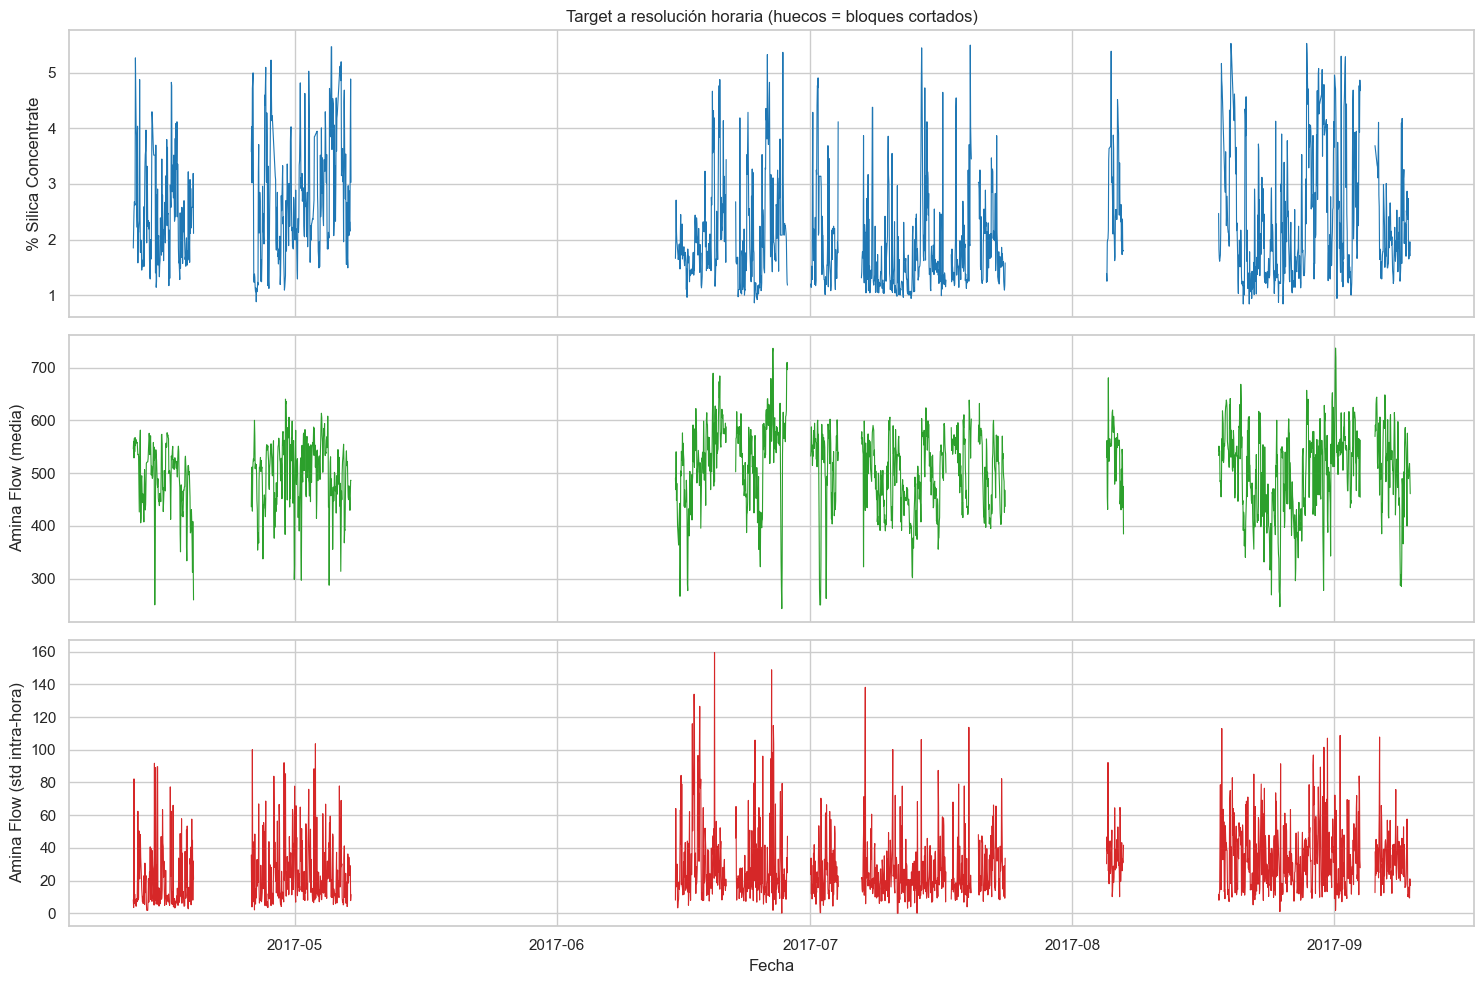

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Target por bloque
for b in bloques:
    axes[0].plot(b[TIMESTAMP_COL], b[TARGET], linewidth=0.8, color="#1f77b4")
axes[0].set_ylabel(TARGET)
axes[0].set_title("Target a resolución horaria (huecos = bloques cortados)")

# Una media y su std, para ver que la std aporta señal propia
var = "Amina Flow"
for b in bloques:
    axes[1].plot(b[TIMESTAMP_COL], b[f"{var}_mean"], linewidth=0.8, color="#2ca02c")
    axes[2].plot(b[TIMESTAMP_COL], b[f"{var}_std"], linewidth=0.8, color="#d62728")
axes[1].set_ylabel(f"{var} (media)")
axes[2].set_ylabel(f"{var} (std intra-hora)")
axes[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Si el panel inferior (std) tuviera una forma parecida al del medio (media), la std sería
redundante. Si tiene dinámica propia —picos donde la media está plana— está aportando
información que la media sola no captura, y ha valido la pena calcularla.

In [14]:
# ¿Cuánta información nueva aporta la std frente a su media?
corr_mean_std = []
for c in cols_mean:
    base = c[:-5]
    if f"{base}_std" in horario.columns:
        r = horario[c].corr(horario[f"{base}_std"])
        corr_mean_std.append({"variable": base, "corr(mean, std)": r})

df_corr = pd.DataFrame(corr_mean_std).sort_values("corr(mean, std)",
                                                  key=abs, ascending=False)
print("Correlación entre la media y la std de cada variable:")
print("(|r| alto = la std es casi redundante)\n")
df_corr.round(3).to_string(index=False)

Correlación entre la media y la std de cada variable:
(|r| alto = la std es casi redundante)



c:\Users\COMPUTAEX\anaconda3\envs\aove\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\COMPUTAEX\anaconda3\envs\aove\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


'                    variable  corr(mean, std)\nFlotation Column 06 Air Flow            0.407\nFlotation Column 04 Air Flow            0.224\n   Flotation Column 04 Level           -0.203\nFlotation Column 07 Air Flow            0.176\n          % Iron Concentrate           -0.159\n               Ore Pulp Flow            0.157\n            Ore Pulp Density           -0.156\n   Flotation Column 07 Level           -0.155\nFlotation Column 02 Air Flow            0.118\n   Flotation Column 06 Level           -0.101\n                 Starch Flow            0.088\n   Flotation Column 02 Level           -0.087\n   Flotation Column 01 Level            0.056\n   Flotation Column 03 Level            0.054\nFlotation Column 01 Air Flow           -0.049\nFlotation Column 05 Air Flow           -0.049\n                 Ore Pulp pH           -0.037\n                  Amina Flow           -0.028\nFlotation Column 03 Air Flow           -0.023\n   Flotation Column 05 Level           -0.023\n            

## 9. Distribución del target y chequeo de régimen

Ya sabes que hay un cambio de régimen en el tramo final. A resolución horaria se ve
mucho mejor cuánto tramo abarca y cuántas muestras reales tiene.

In [15]:
dataset = pd.concat(bloques, ignore_index=True).sort_values(TIMESTAMP_COL)
dataset = dataset.reset_index(drop=True)

corte = int(len(dataset) * 0.8)
tr_ref, te_ref = dataset.iloc[:corte], dataset.iloc[corte:]

print(f"Si se hiciera split 80/20 cronológico:")
print(f"  Train: {len(tr_ref):>5} h | {tr_ref[TIMESTAMP_COL].min()} -> "
      f"{tr_ref[TIMESTAMP_COL].max()}")
print(f"  Test : {len(te_ref):>5} h | {te_ref[TIMESTAMP_COL].min()} -> "
      f"{te_ref[TIMESTAMP_COL].max()}")
print(f"\n  Media target — train: {tr_ref[TARGET].mean():.3f} | "
      f"test: {te_ref[TARGET].mean():.3f}")
print(f"  Std   target — train: {tr_ref[TARGET].std():.3f} | "
      f"test: {te_ref[TARGET].std():.3f}")

Si se hiciera split 80/20 cronológico:
  Train:  1405 h | 2017-04-11 22:00:00 -> 2017-08-24 14:00:00
  Test :   352 h | 2017-08-24 15:00:00 -> 2017-09-09 23:00:00

  Media target — train: 2.273 | test: 2.487
  Std   target — train: 1.046 | test: 1.163


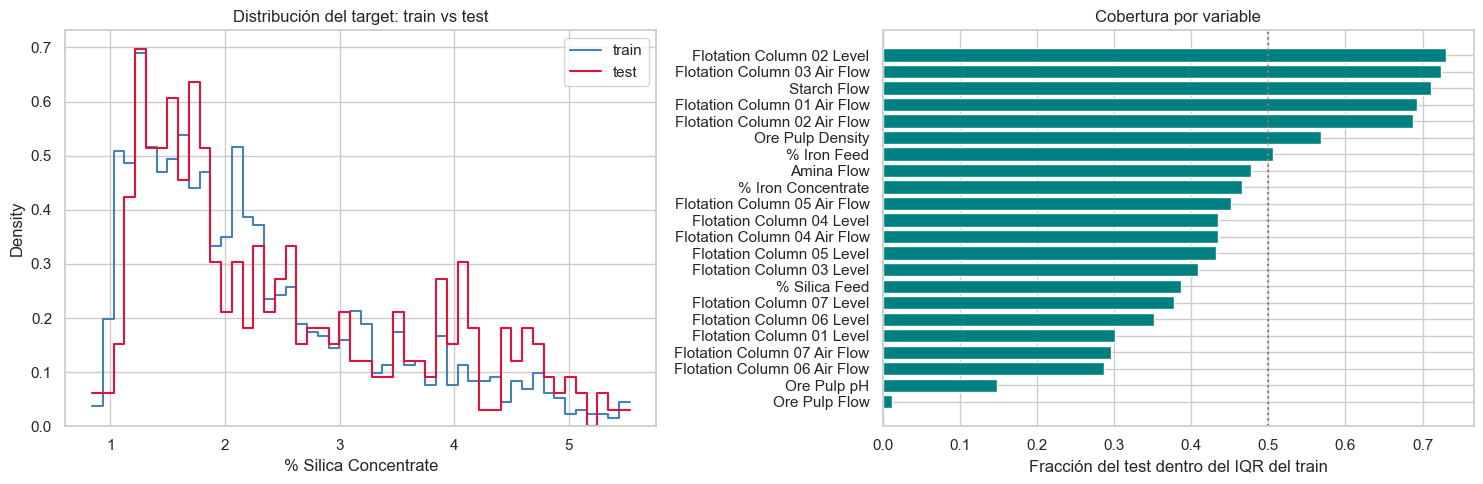

Variables peor cubiertas (el modelo extrapolará en ellas):


'                    variable  cobertura_IQR\n               Ore Pulp Flow          0.011\n                 Ore Pulp pH          0.148\nFlotation Column 06 Air Flow          0.287\nFlotation Column 07 Air Flow          0.295\n   Flotation Column 01 Level          0.301'

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(tr_ref[TARGET], color="steelblue", stat="density", bins=50,
             label="train", element="step", fill=False, ax=axes[0])
sns.histplot(te_ref[TARGET], color="crimson", stat="density", bins=50,
             label="test", element="step", fill=False, ax=axes[0])
axes[0].set_title("Distribución del target: train vs test")
axes[0].legend()

# Cobertura: fracción del test dentro del rango intercuartílico del train
filas = []
for c in cols_mean:
    q1, q3 = tr_ref[c].quantile([0.25, 0.75])
    dentro = te_ref[c].between(q1, q3).mean()
    filas.append({"variable": c.replace("_mean", ""), "cobertura_IQR": dentro})

cob = pd.DataFrame(filas).sort_values("cobertura_IQR")
axes[1].barh(cob["variable"], cob["cobertura_IQR"], color="teal")
axes[1].axvline(0.5, color="gray", linestyle=":")
axes[1].set_xlabel("Fracción del test dentro del IQR del train")
axes[1].set_title("Cobertura por variable")

plt.tight_layout()
plt.show()

print("Variables peor cubiertas (el modelo extrapolará en ellas):")
cob.head(5).round(3).to_string(index=False)

El panel derecho es la versión numérica de lo que viste a ojo en los histogramas. Una
cobertura cercana a cero significa que en el test esa variable vive en un rango que el
modelo nunca observó — los árboles la tratarán como constante y el PLS extrapolará
linealmente. Ninguna de las dos cosas es fiable, pero al menos el PLS te lo señalará con
sus estadísticos de diagnóstico en el notebook 04.

## 10. Guardar

In [17]:
# Se guarda el dataset ya troceado, con un identificador de bloque, para que el
# notebook 04 pueda construir lags sin cruzar fronteras.
piezas = []
for i, b in enumerate(bloques):
    b = b.copy()
    b["bloque_id"] = i
    piezas.append(b)

final = pd.concat(piezas, ignore_index=True).sort_values(TIMESTAMP_COL)
final = final.reset_index(drop=True)

final.to_parquet(OUTPUT_PATH, index=False)

print(f"Guardado en {OUTPUT_PATH.resolve()}")
print(f"  {len(final):,} horas | {final.shape[1]} columnas | "
      f"{len(bloques)} bloques")
print(f"  {final[TIMESTAMP_COL].min()} -> {final[TIMESTAMP_COL].max()}")

# El notebook 04 espera esta bandera para el análisis de sensibilidad
assert "target_ruidoso" in final.columns, "Falta la bandera target_ruidoso"
print(f"  Horas con target ruidoso conservadas: "
      f"{final['target_ruidoso'].sum():,} ({final['target_ruidoso'].mean():.1%})")
final.head(3)

Guardado en C:\Users\COMPUTAEX\Documents\Gerardo\AOVE2\mining_process_dataset\datos_horarios.parquet
  1,757 horas | 48 columnas | 11 bloques
  2017-04-11 22:00:00 -> 2017-09-09 23:00:00
  Horas con target ruidoso conservadas: 112 (6.4%)


,date,% Silica Concentrate,% Iron Feed_mean,% Iron Feed_std,% Silica Feed_mean,% Silica Feed_std,Starch Flow_mean,Starch Flow_std,Amina Flow_mean,Amina Flow_std,Ore Pulp Flow_mean,Ore Pulp Flow_std,Ore Pulp pH_mean,Ore Pulp pH_std,Ore Pulp Density_mean,Ore Pulp Density_std,Flotation Column 01 Air Flow_mean,Flotation Column 01 Air Flow_std,Flotation Column 02 Air Flow_mean,Flotation Column 02 Air Flow_std,Flotation Column 03 Air Flow_mean,Flotation Column 03 Air Flow_std,Flotation Column 04 Air Flow_mean,Flotation Column 04 Air Flow_std,Flotation Column 05 Air Flow_mean,Flotation Column 05 Air Flow_std,Flotation Column 06 Air Flow_mean,Flotation Column 06 Air Flow_std,Flotation Column 07 Air Flow_mean,Flotation Column 07 Air Flow_std,Flotation Column 01 Level_mean,Flotation Column 01 Level_std,Flotation Column 02 Level_mean,Flotation Column 02 Level_std,Flotation Column 03 Level_mean,Flotation Column 03 Level_std,Flotation Column 04 Level_mean,Flotation Column 04 Level_std,Flotation Column 05 Level_mean,Flotation Column 05 Level_std,Flotation Column 06 Level_mean,Flotation Column 06 Level_std,Flotation Column 07 Level_mean,Flotation Column 07 Level_std,% Iron Concentrate_mean,% Iron Concentrate_std,target_ruidoso,bloque_id
0,2017-04-11 22:00:00,1.847283,57.91,0.0,10.54,0.0,1960.839872,494.928558,545.920567,8.282939,399.396733,3.859102,8.987119,0.109289,1.742088,0.006453,249.905400,0.412646,249.834922,3.639527,250.141411,1.083782,296.506228,0.005119,304.995247,0.03603,249.544539,0.577602,249.826578,0.945741,600.922389,17.556537,598.804856,17.245315,598.677650,9.305145,286.092137,138.480014,449.350300,6.980051,451.225594,6.630497,454.249750,6.186460,65.325166,0.026005,True,0
1,2017-04-11 23:00:00,2.180000,57.91,0.0,10.54,0.0,2364.042128,432.583778,560.131878,3.466656,398.967889,3.850757,9.643406,0.186777,1.763131,0.003675,249.897250,1.322364,249.950506,2.785887,250.017789,1.040832,296.488545,0.005119,304.870780,0.03603,249.818972,0.762358,250.004200,1.496856,599.937917,9.899713,599.604544,8.648226,600.944844,7.120297,455.449444,16.290548,451.296500,7.511985,450.246733,11.438787,452.246850,7.582721,65.415000,0.026005,True,0
2,2017-04-12 00:00:00,2.512717,57.91,0.0,10.54,0.0,2530.929883,387.282634,528.630200,82.196991,400.833553,5.141238,9.908975,0.028579,1.695828,0.098423,250.204594,1.705436,249.942861,3.247461,250.149100,0.894419,296.470861,0.005119,304.746312,0.03603,250.152567,0.434465,250.024372,1.563406,608.360056,31.379054,617.410619,58.974298,603.468894,44.888691,450.706650,86.899235,449.293861,30.727472,456.389789,44.785752,451.171781,54.001398,65.504834,0.026005,True,0


## 11. Resumen

Anota estos números antes de pasar al notebook 04:

- [ ] Horas útiles totales:
- [ ] Número de features (mean + std):
- [ ] Ratio muestras/feature con 3 lags:
- [ ] ¿Aporta la std información propia, o replica a la media?
- [ ] ¿Qué variables tienen cobertura baja en el tramo final?
- [ ] ¿Cuántas horas quedan marcadas como target ruidoso?

Si la ratio con lags está por debajo de 10, ve al notebook 04 esperando que el PLS
compita de tú a tú con XGBoost — y no lo interpretes como que XGBoost "falló", sino como
que el problema tiene el tamaño que tiene.